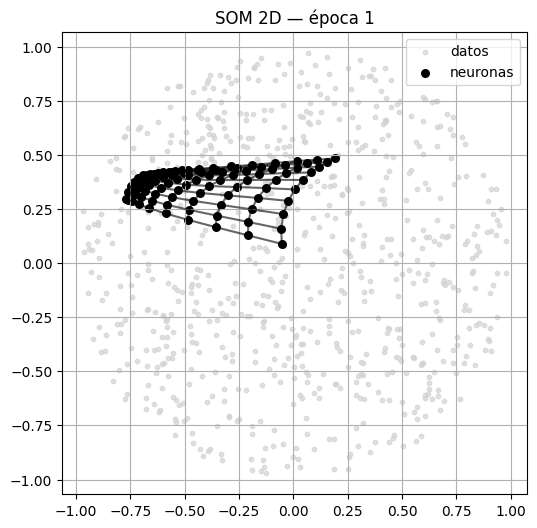

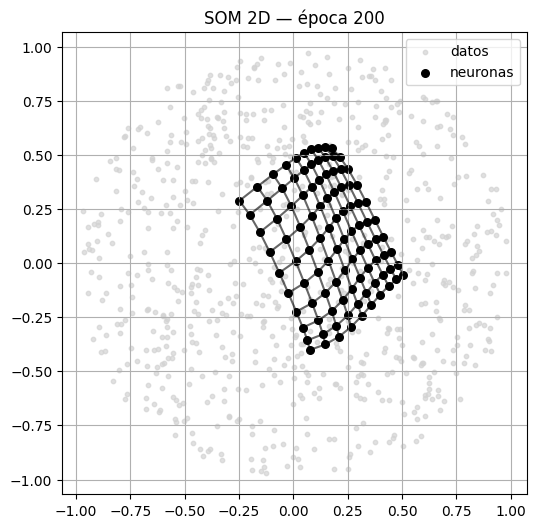

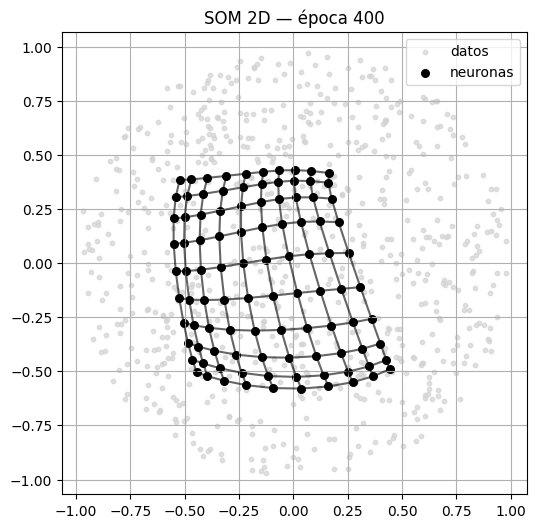

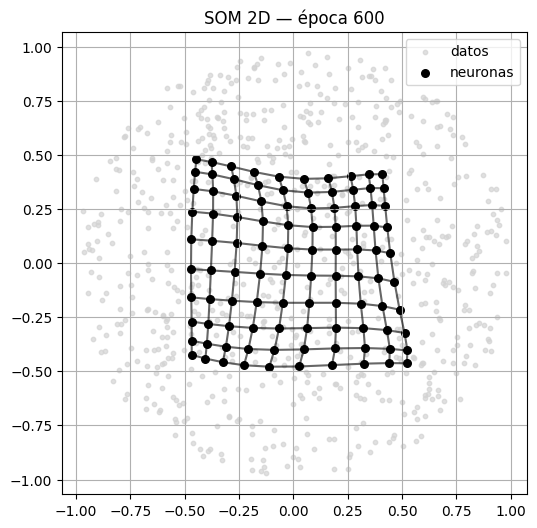

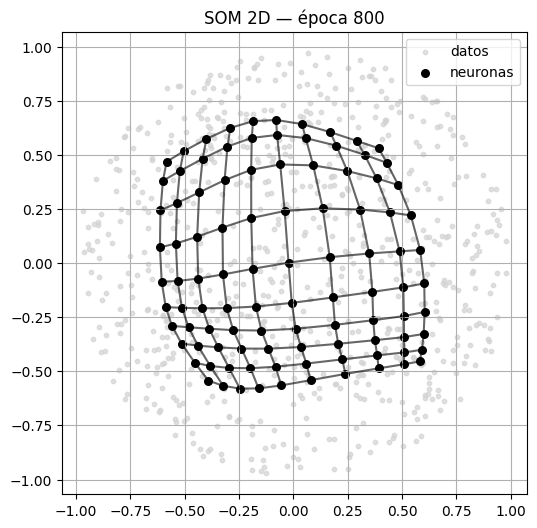

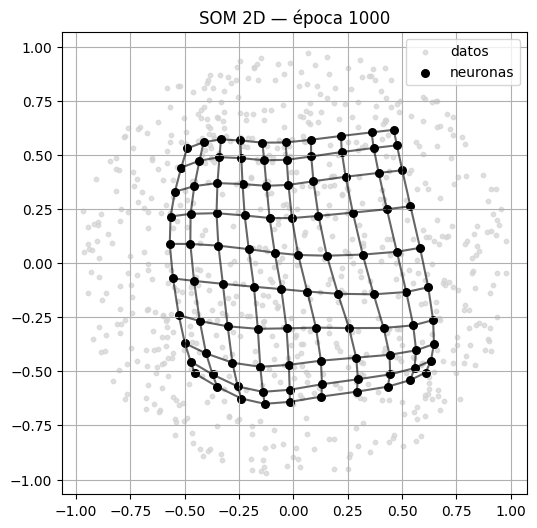

C:\Users\nacho\AppData\Local\Temp\ipykernel_31592\486400175.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = cm.get_cmap('tab20', f*c)


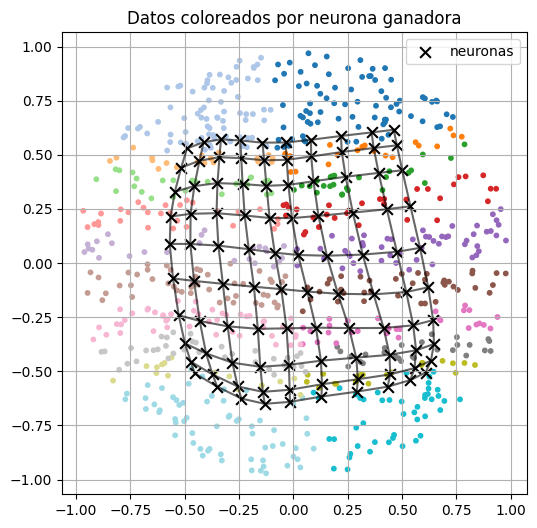

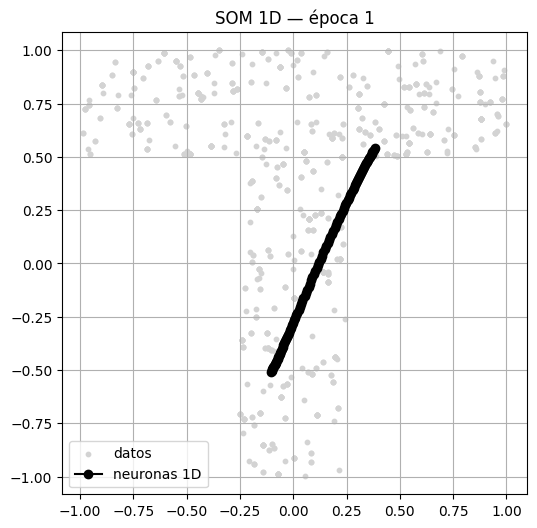

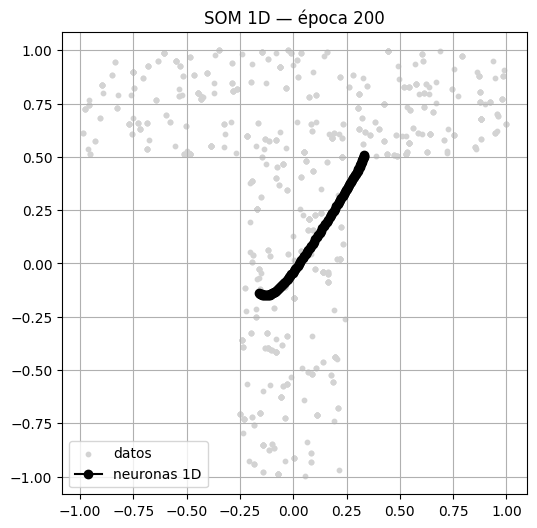

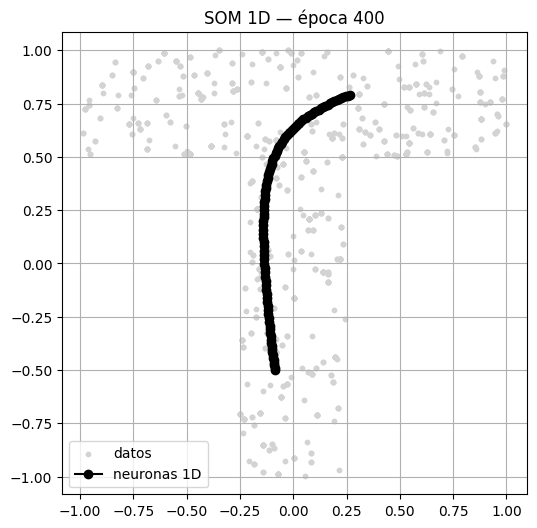

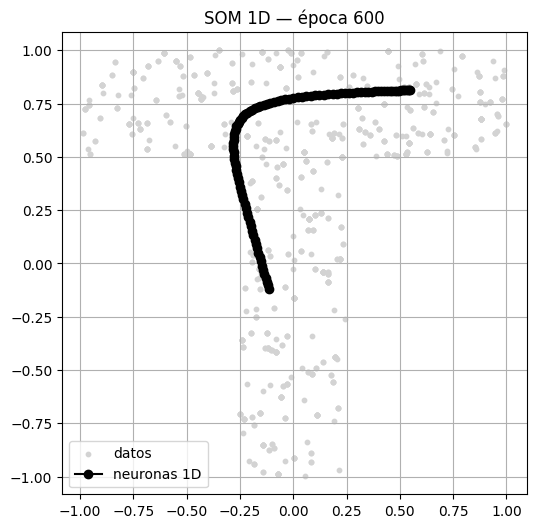

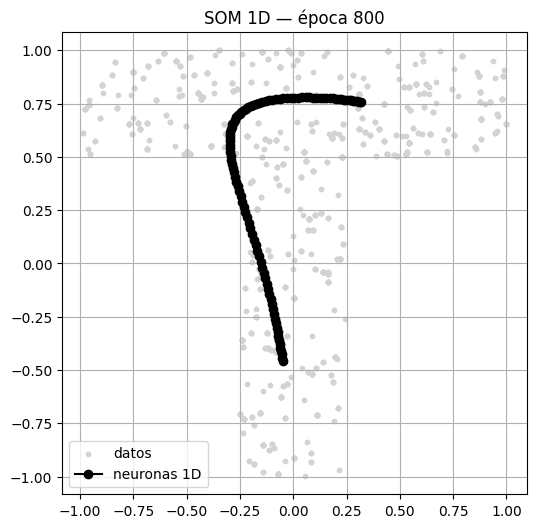

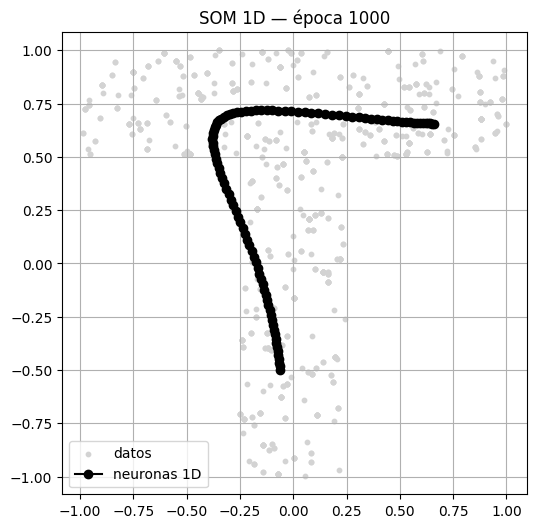

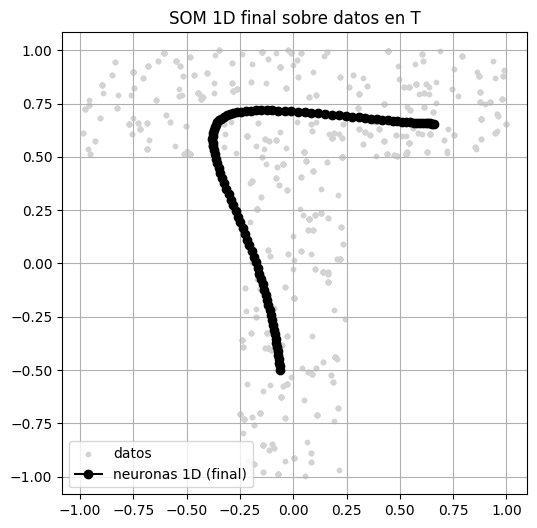

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from matplotlib import cm

# -----------------------------
# Utilidades de E/S
# -----------------------------
def leer_csv(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        r = csv.reader(f)
        for fila in r:
            if not fila:        # línea vacía
                continue
            x1, x2 = map(float, fila[:2])
            data.append([x1, x2])
    return np.array(data)

# -----------------------------
# SOM 2D
# -----------------------------
def inicializar_som_2d(filas, cols, low=-0.5, high=0.5):
    # pesos con shape (filas, cols, 2)
    return np.random.uniform(low, high, size=(filas, cols, 2))

def bmu_2d(W, x):
    # Best Matching Unit (neurona ganadora) por distancia euclídea
    # W: (f,c,2) ; x: (2,)
    dist2 = np.sum((W - x)**2, axis=2)       # (f,c)
    return np.unravel_index(np.argmin(dist2), dist2.shape)  # (i,j)

def actualizar_vecindad_2d(W, x, bmu, alpha, sigma):
    # Actualiza BMU y vecinas con vecindad Gaussiana en la grilla (i,j)
    f, c = W.shape[:2]
    I, J = np.meshgrid(np.arange(f), np.arange(c), indexing='ij')  # coords de la grilla
    di = I - bmu[0]; dj = J - bmu[1]
    d2 = di**2 + dj**2
    h = np.exp(-d2 / (2 * (sigma**2)))        # (f,c)
    W += (alpha * h)[..., None] * (x - W)     # broadcasting
    return W

def plot_mapa(W, data=None, titulo=""):
    plt.figure(figsize=(6,6))
    if data is not None:
        plt.scatter(data[:,0], data[:,1], s=10, c='lightgray', alpha=0.7, label='datos')
    # neuronas (centroides)
    f, c = W.shape[:2]
    plt.scatter(W[...,0].ravel(), W[...,1].ravel(), c='k', s=30, label='neuronas')
    # líneas entre vecinas (ordenamiento topológico)
    for i in range(f):           # filas
        plt.plot(W[i,:,0], W[i,:,1], 'k-', alpha=0.6)
    for j in range(c):           # columnas
        plt.plot(W[:,j,0], W[:,j,1], 'k-', alpha=0.6)
    plt.title(titulo)
    plt.axis('equal'); plt.grid(True); plt.legend()
    plt.show()

def entrenar_som_2d(data, filas=10, cols=10, epocas=1000, alpha0=0.5, sigma0=None, plot_every=200):
    if sigma0 is None:
        sigma0 = max(filas, cols) / 2.0
    W = inicializar_som_2d(filas, cols)
    N = len(data)

    for ep in range(1, epocas+1):
        np.random.shuffle(data)
        # decaimiento exponencial (podés cambiar por lineal si querés)
        alpha = alpha0 * np.exp(-ep / epocas)
        sigma = sigma0 * np.exp(-ep / epocas)

        for x in data:
            bmu = bmu_2d(W, x)
            W = actualizar_vecindad_2d(W, x, bmu, alpha, sigma)

        # ver el mapa durante el proceso
        if ep == 1 or ep % plot_every == 0 or ep == epocas:
            plot_mapa(W, data, titulo=f"SOM 2D — época {ep}")

    return W

def colorear_por_ganadora(W, data):
    f, c = W.shape[:2]
    colores = cm.get_cmap('tab20', f*c)
    labels = []
    for x in data:
        i, j = bmu_2d(W, x)
        labels.append(i*c + j)
    labels = np.array(labels)

    plt.figure(figsize=(6,6))
    sc = plt.scatter(data[:,0], data[:,1], c=labels, cmap=colores, s=10)
    # centroides y líneas
    plt.scatter(W[...,0].ravel(), W[...,1].ravel(), c='k', marker='x', s=60, label='neuronas')
    for i in range(f):
        plt.plot(W[i,:,0], W[i,:,1], 'k-', alpha=0.6)
    for j in range(c):
        plt.plot(W[:,j,0], W[:,j,1], 'k-', alpha=0.6)
    plt.title("Datos coloreados por neurona ganadora")
    plt.axis('equal'); plt.grid(True); plt.legend()
    plt.show()

# -----------------------------
# SOM 1D (para el dataset T)
# -----------------------------
def inicializar_som_1d(n, low=-0.5, high=0.5):
    # pesos con shape (n, 2)
    return np.random.uniform(low, high, size=(n, 2))

def bmu_1d(W, x):
    return np.argmin(np.sum((W - x)**2, axis=1))

def actualizar_vecindad_1d(W, x, idx, alpha, sigma):
    n = W.shape[0]
    i = np.arange(n)
    d2 = (i - idx)**2
    h = np.exp(-d2 / (2 * (sigma**2)))
    W += (alpha * h)[:, None] * (x - W)
    return W

def entrenar_som_1d(data, n_neuronas, epocas=1000, alpha0=0.5, sigma0=None, plot_every=200):
    if sigma0 is None:
        sigma0 = n_neuronas / 2.0
    W = inicializar_som_1d(n_neuronas)

    for ep in range(1, epocas+1):
        np.random.shuffle(data)
        alpha = alpha0 * np.exp(-ep / epocas)
        sigma = sigma0 * np.exp(-ep / epocas)

        for x in data:
            idx = bmu_1d(W, x)
            W = actualizar_vecindad_1d(W, x, idx, alpha, sigma)

        if ep == 1 or ep % plot_every == 0 or ep == epocas:
            plt.figure(figsize=(6,6))
            plt.scatter(data[:,0], data[:,1], s=10, c='lightgray', label='datos')
            plt.plot(W[:,0], W[:,1], 'k-o', label='neuronas 1D')
            plt.title(f"SOM 1D — época {ep}")
            plt.axis('equal'); plt.grid(True); plt.legend()
            plt.show()

    return W

# -----------------------------
# EJECUCIÓN
# -----------------------------
if __name__ == "__main__":
    # 1) Círculo (SOM 2D)
    datos_circulo = leer_csv("te.csv")
    W2D = entrenar_som_2d(datos_circulo, filas=10, cols=10, epocas=1000,
                          alpha0=0.4, sigma0=None, plot_every=200)
    # colorear por BMU y marcar centroides
    colorear_por_ganadora(W2D, datos_circulo)

    # 2) T (SOM 1D con la misma cantidad de neuronas)
    total_neuronas = W2D.shape[0] * W2D.shape[1]
    datos_T = leer_csv("te.csv")
    W1D = entrenar_som_1d(datos_T, n_neuronas=total_neuronas, epocas=1000,
                          alpha0=0.4, sigma0=None, plot_every=200)

    # dibujo final del 1D
    plt.figure(figsize=(6,6))
    plt.scatter(datos_T[:,0], datos_T[:,1], s=10, c='lightgray', label='datos')
    plt.plot(W1D[:,0], W1D[:,1], 'k-o', label='neuronas 1D (final)')
    plt.title("SOM 1D final sobre datos en T")
    plt.axis('equal'); plt.grid(True); plt.legend()
    plt.show()
